## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara 237864
## Semestre: Enero_Junio del 2026

---

# Practica 33 test de normalidad y suavizado
Lo primero que se debe hacer a una serie de tiempo, es el tes de normalidad de los residuos (diferencias). ¿qué quiere decier esto? QUe los datos de los residuos (diferencias) siguen una curva normal.


## Paso 1: Pargar los datos del mercado de valores

In [6]:
#setwd("C:/R/SERIES_TIEMPO/Datos")
setwd("C:/Users/memoo/Documents/git/MDL-2026/Practica 31")
stock_data <- read.csv("stockdata.csv", header = TRUE, dec= ",", sep=";")
head(stock_data)
dim(stock_data)
summary(stock_data)

,date,open,high,low,close,volume
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,20020514,29.01,29.29,28.70,29.00,422606
2,20020513,28.81,29.15,28.71,28.93,265548
3,20020510,29.30,29.49,28.38,28.69,497579
4,20020509,29.26,29.78,28.82,29.01,342824
5,20020508,28.50,29.80,28.41,29.70,559890
6,20020507,29.50,29.65,27.85,28.21,716809


[1] 589   6

      date               open            high            low       
 Min.   :20000103   Min.   :19.00   Min.   :21.00   Min.   :17.15  
 1st Qu.:20000731   1st Qu.:33.30   1st Qu.:33.98   1st Qu.:32.86  
 Median :20010227   Median :36.62   Median :37.34   Median :36.00  
 Mean   :20007818   Mean   :37.05   Mean   :37.70   Mean   :36.30  
 3rd Qu.:20011004   3rd Qu.:40.32   3rd Qu.:40.69   3rd Qu.:39.53  
 Max.   :20020514   Max.   :58.25   Max.   :58.50   Max.   :54.44  
     close           volume       
 Min.   :19.20   Min.   :  73239  
 1st Qu.:33.40   1st Qu.: 349907  
 Median :36.56   Median : 448416  
 Mean   :36.95   Mean   : 546857  
 3rd Qu.:40.01   3rd Qu.: 618137  
 Max.   :55.28   Max.   :7031178  

## Paso 2: Graficar la serie de tiempo, para verificar los posibles atipicidades.

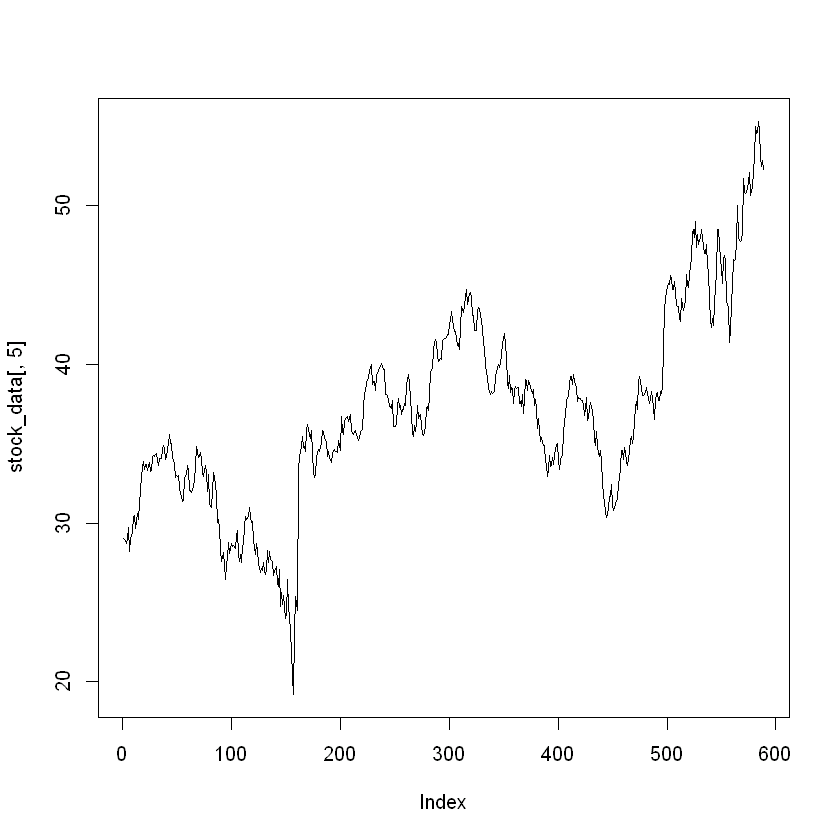

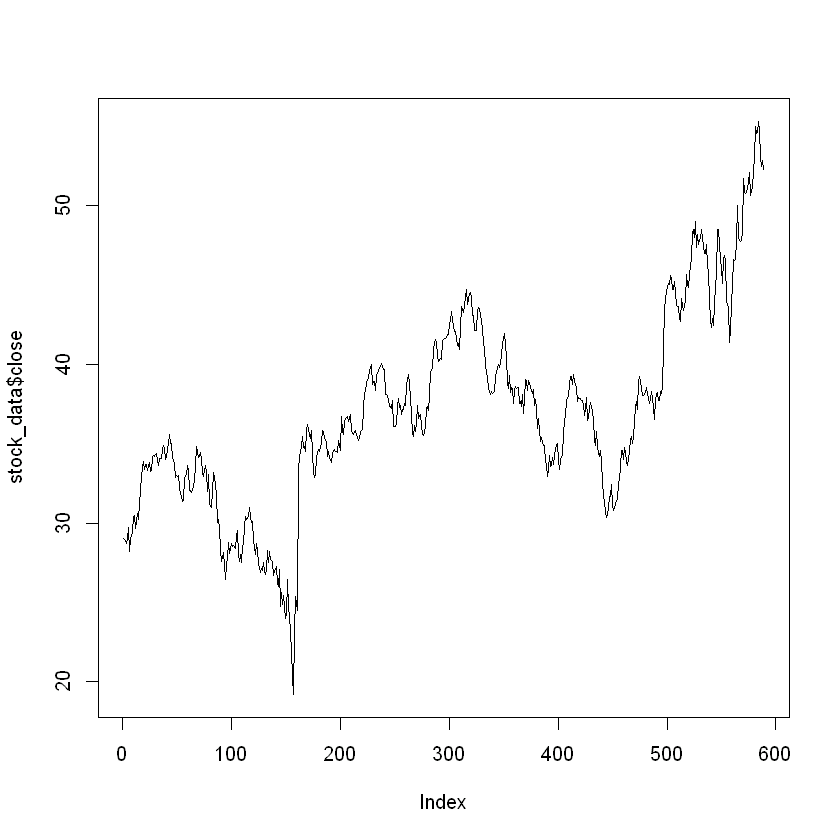

In [7]:
## Grafica series de tiempo para el volumen

plot(stock_data[,5], type = "l")
## Grafica series de tiempo para el precio de cierre.
plot(stock_data$close, type = "l")

### Paso 3: Mostrar posibles atipicidades

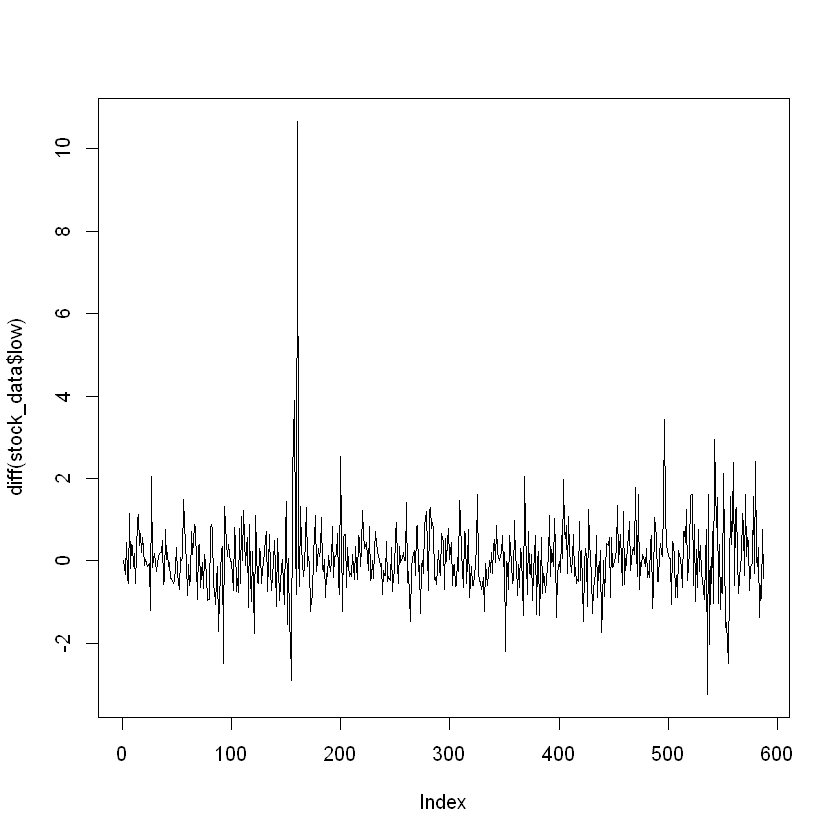

In [11]:
# Grafica para mostrar atipicidades
plot(diff(stock_data$low), type = "l")


## Paso 4: en ocasiones se aplica un logaritmo para suavizar la serie

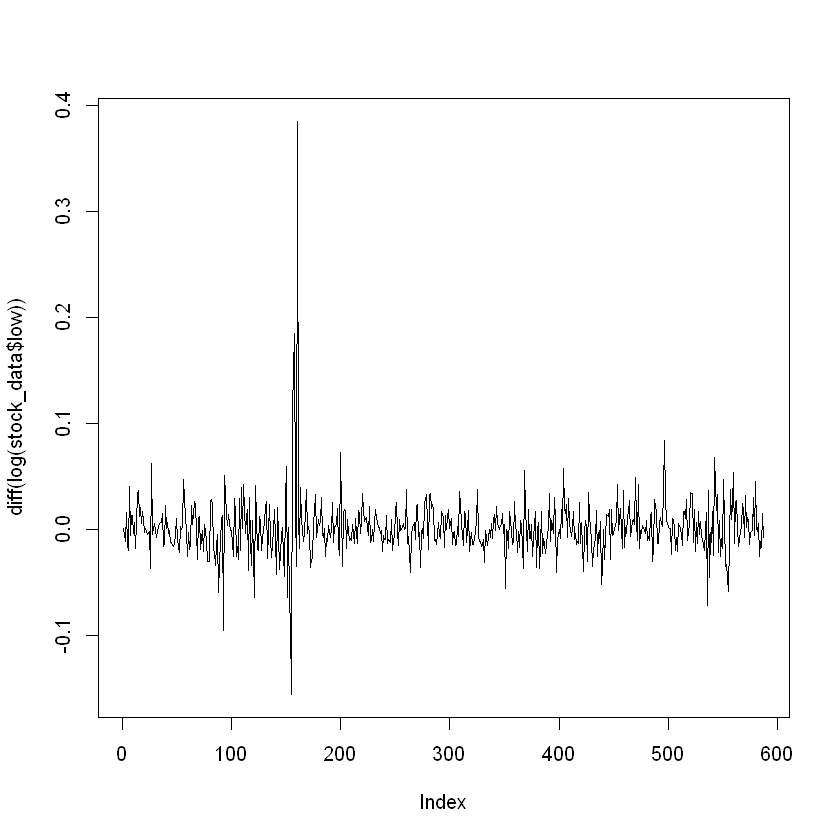

In [10]:
plot(diff(log(stock_data$low)), type = "l")


### Paso 5: Probar el operador **diff** para realizar test de normalidad de los residuos

In [12]:
diff(1:10, 1)
diff(c(9, 2, 3, 1, 6, 7), 1)

[1] 1 1 1 1 1 1 1 1 1

[1] -7  1 -2  5  1

### Paso 6: Generar el histograma y la normal perfecta

[1] 0.03940476

[1] 0.8986914

[1] -4.00000000 -3.91919192 -3.83838384 -3.75757576 -3.67676768 -3.59595960
  [7] -3.51515152 -3.43434343 -3.35353535 -3.27272727 -3.19191919 -3.11111111
 [13] -3.03030303 -2.94949495 -2.86868687 -2.78787879 -2.70707071 -2.62626263
 [19] -2.54545455 -2.46464646 -2.38383838 -2.30303030 -2.22222222 -2.14141414
 [25] -2.06060606 -1.97979798 -1.89898990 -1.81818182 -1.73737374 -1.65656566
 [31] -1.57575758 -1.49494949 -1.41414141 -1.33333333 -1.25252525 -1.17171717
 [37] -1.09090909 -1.01010101 -0.92929293 -0.84848485 -0.76767677 -0.68686869
 [43] -0.60606061 -0.52525253 -0.44444444 -0.36363636 -0.28282828 -0.20202020
 [49] -0.12121212 -0.04040404  0.04040404  0.12121212  0.20202020  0.28282828
 [55]  0.36363636  0.44444444  0.52525253  0.60606061  0.68686869  0.76767677
 [61]  0.84848485  0.92929293  1.01010101  1.09090909  1.17171717  1.25252525
 [67]  1.33333333  1.41414141  1.49494949  1.57575758  1.65656566  1.73737374
 [73]  1.81818182  1.89898990  1.97979798  2.06060606  2.14141414  2.22222222
 [79]  2.30303030  2.38383838  2.46464646  2.54545455  2.62626263  2.70707071
 [85]  2.78787879  2.86868687  2.94949495  3.03030303  3.11111111  3.19191919
 [91]  3.27272727  3.35353535  3.43434343  3.51515152  3.59595960  3.67676768
 [97]  3.75757576  3.83838384  3.91919192  4.00000000

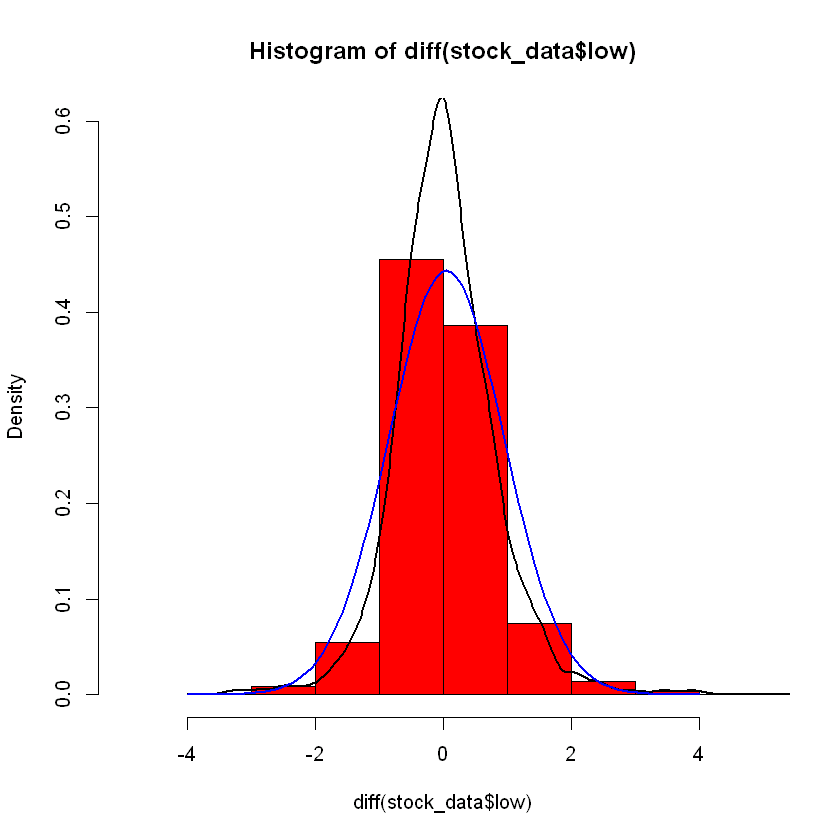

In [17]:
hist(diff(stock_data$low), prob=T, ylim = c(0,0.6), xlim = c(-5, 5), col = "red")
lines(density(diff(stock_data$low)), lwd = 2)
mu <- mean(diff(stock_data$low))
mu
sigma <- sd(diff(stock_data$low))
sigma
x <- seq(-4, 4, length=100)
x
y <- dnorm(x, mean = mu, sd = sigma)
lines(x, y, lwd = 2, col = "blue")

### La prueba de la normalidad busca comprobar que la curva de datos (negra) se encuentre dentro del rango de la curva azul, que es la normal perfecta. ¿Que? Pues que si la curva negra esta fuera del rango, implica que los datos no se estan comportando de manera normal. 

### Paso 7: Aplicar el filtro de medias moviles, para suavizar la serie

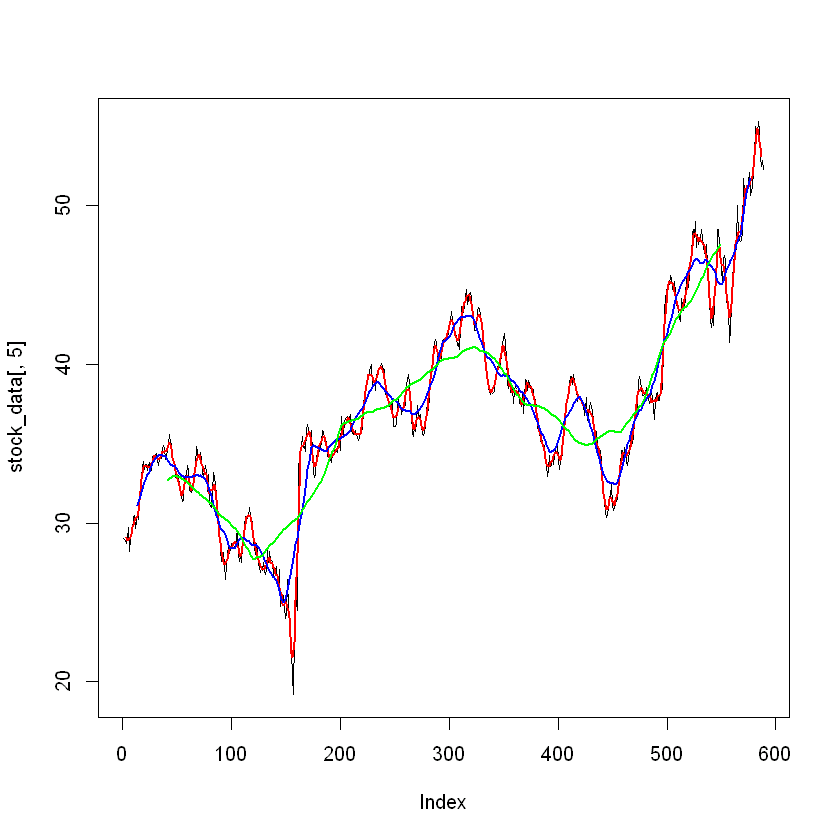

In [18]:
plot(stock_data[,5], type = "l")
st_1 <- filter(stock_data[,5], filter = rep(1/5,5))
st_2 <- filter(stock_data[,5], filter = rep(1/25,25))
st_3 <- filter(stock_data[,5], filter = rep(1/81, 81))
lines(st_1, col = "red", lwd = 2)
lines(st_2, col = "blue", lwd = 2)
lines(st_3, col = "green", lwd = 2)

### Conclusiones

En esta practica implementamos el test de normalidad y suavizado para las series de tiempo referente al meracado de valores de ahooy finanzas.


## Referencias
- NOAA Earth System Research Laboratory. CO2 dataset via `statsmodels.datasets.co2`
- Royal Observatory of Belgium – SIDC. Sunspot data via `statsmodels.datasets.sunspots`